Importing required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\uttam\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis (EDA)

The objective of thiss EDA is to understand customer behavior, identify patterns associated with churn, and uncover key factors that influence customer attrition.

In [3]:
# Total rows and columns
print("Dataset shape:", df.shape)


Dataset shape: (7043, 21)


In [4]:
# Basic info
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

In [5]:
# Churn distribution
churn_percent = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f"\nChurn Percentage: {churn_percent:.2f}%")


Churn Percentage: 26.54%


### Initial Observation
Approximately 26.54% of customers have churned, indicating a significant potential impact on revenue and customer retention. Early identification of churn drivers can help in reducing losses.

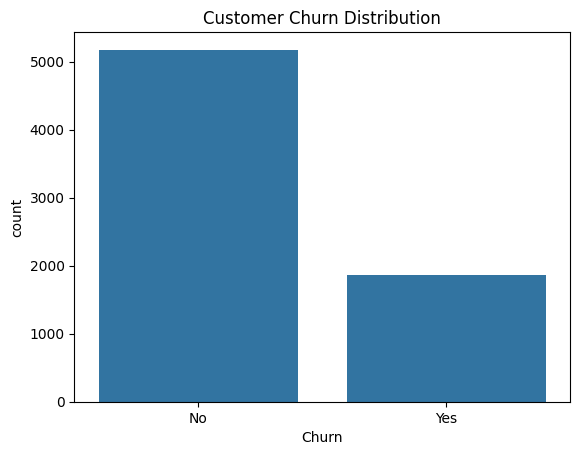

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

**Insight:** Customers who churned are fewer than non-churned, but they represent a significant risk to revenue.

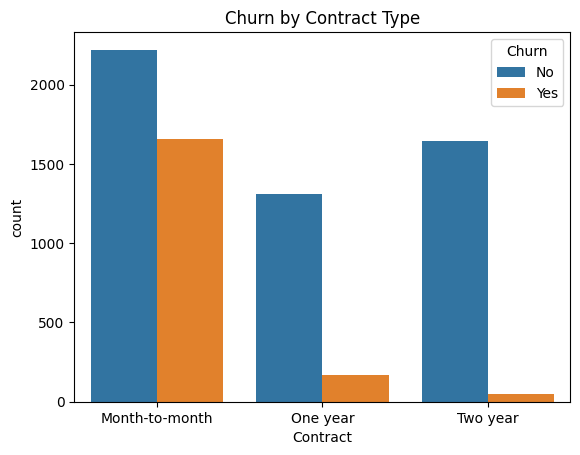

In [5]:
# Churn rate by contract type
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

# Plot
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

**Insight:** Customers on month-to-month contracts churn at a much higher rate than those on one- or two-year contracts.  
**Action:** Offer incentives or long-term plans to month-to-month customers to reduce churn.

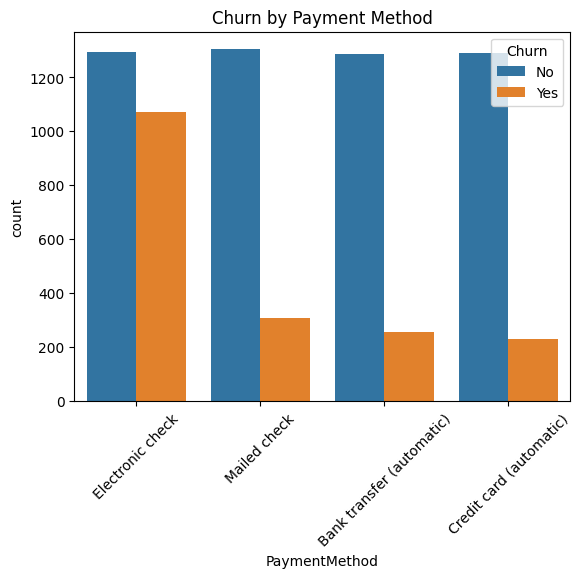

In [6]:
# Churn rate by payment method
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

# Plot
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

**Insight:** Customers using electronic check payment have higher churn compared to other payment methods.  
**Action:** Offer reminders, auto-pay options, or loyalty incentives to electronic check customers.

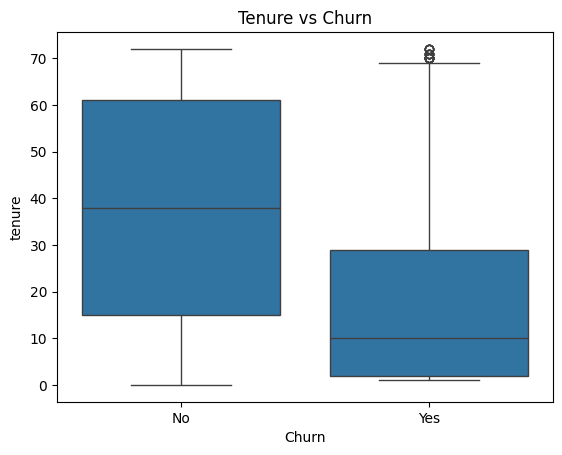

In [7]:
# Boxplot
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

**Insight:** Customers with shorter tenure are more likely to churn.  
**Action:** Focus retention efforts on new customers with personalized onboarding and early incentives.

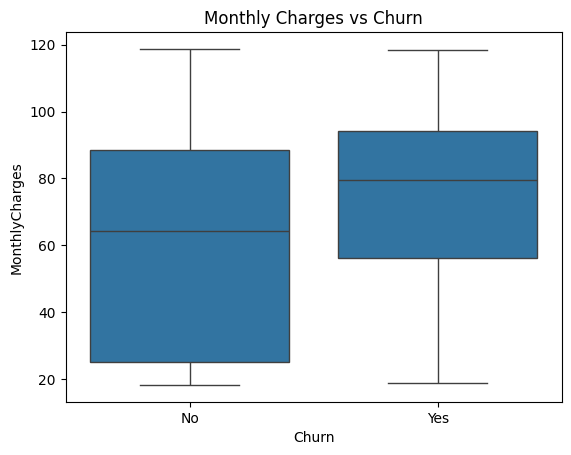

In [8]:
# Boxplot
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Insight:** Customers with higher monthly charges tend to churn more.  
**Action:** Consider offering discounts or flexible plans to high-paying customers to reduce churn risk.

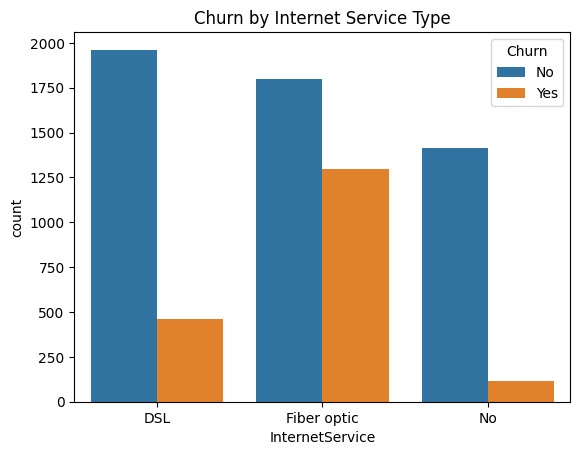

In [9]:
# Churn rate by internet service
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

# Plot
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service Type")
plt.show()

**Insight:** Customers with Fiber optic internet churn more than those with DSL or no internet.  
**Action:** Improve Fiber service quality or provide incentives to high-risk Fiber customers.

### EDA Summary
The analysis reveals that customer churn is primarily driven by contract flexibility, billing behaviour, tenure length, service pricing, and internet service type. Customers with short tenure, month-to-month contracts, higher monthly charges, and electronic check payment methods are significantly more likely to churn.

## Machine Learning Modelling

The objective is to build predictive models that identify customers at high risk of churn, allowing the business to take proactive retention actions.

In [10]:
#Encoding 'Churn'(target) column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

#Dropping non-useful columns
df_model = df.drop(['customerID'], axis=1)

#One-hot encoding categorical variables
df_model = pd.get_dummies(df_model, drop_first=True) #converts categorical variables to numerical format as required by ML algorithms.

In [11]:
#Train-Test Split
# Ensure df_model is defined (from CELL INDEX 22)
from sklearn.model_selection import train_test_split

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
#Standardize numeric features
num_cols = ['tenure', 'MonthlyCharges']

from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
X_train[num_cols] = scalar.fit_transform(X_train[num_cols])
X_test[num_cols] = scalar.transform(X_test[num_cols])

### Model 1: Logistic Regression

In [13]:
#Train model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

#Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

#Evaluation
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

ROC AUC Score: 0.8404169572967527


**Insight:** Logistic Regression provides a strong interpretable baseline with reasonable recall, making it suitable for identifying churn-prone customers.

In [14]:
#Coefficient Interpretation
coef = pd.Series(lr.coef_[0], index=X.columns)
coef.sort_values(ascending=False).head(10)

TotalCharges_20.15             1.351317
TotalCharges_19.9              1.347700
TotalCharges_20.5              1.322540
TotalCharges_20.1              1.181354
TotalCharges_19.6              1.125131
TotalCharges_288.05            1.124827
InternetService_Fiber optic    1.114966
TotalCharges_740.3             1.025298
TotalCharges_19.95             1.024790
TotalCharges_19.45             1.024187
dtype: float64

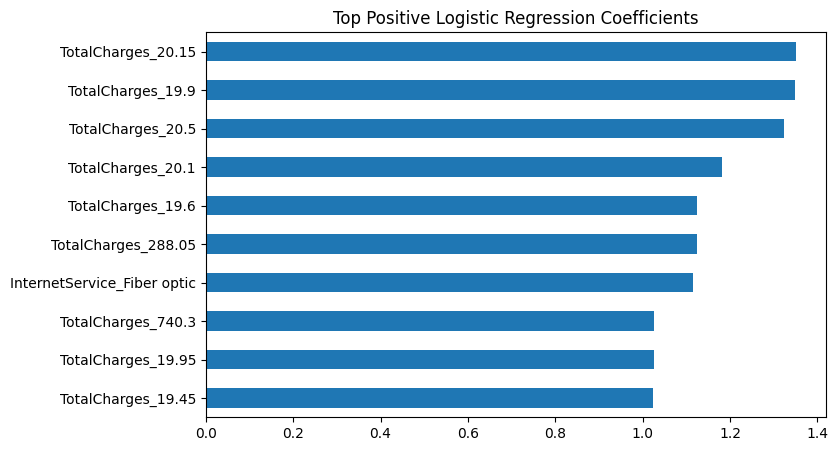

In [15]:
#plotting Top Coefficients
coef.sort_values().tail(10).plot(kind='barh', figsize=(8,5))
plt.title("Top Positive Logistic Regression Coefficients")
plt.show()

### Coefficient Interpretation

After standardizing numeric features, the Logistic Regression model confirms that contract type, internet service type, and pricing-related variables are the strongest drivers of churn. Month-to-month contracts and higher charges significantly increase churn likelihood, while longer tenure acts as a protective factor. Standardization improves coefficient comparability without altering the underlying business insights.

### Model 2: Random Forest

In [16]:
#Train model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

#Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

#Evaluation
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC AUC Score: 0.8287504197990131


**Insight:** Random Forest outperforms Logistic Regression by capturing non-linear relationships and improving churn prediction performance.

## Feature Importance

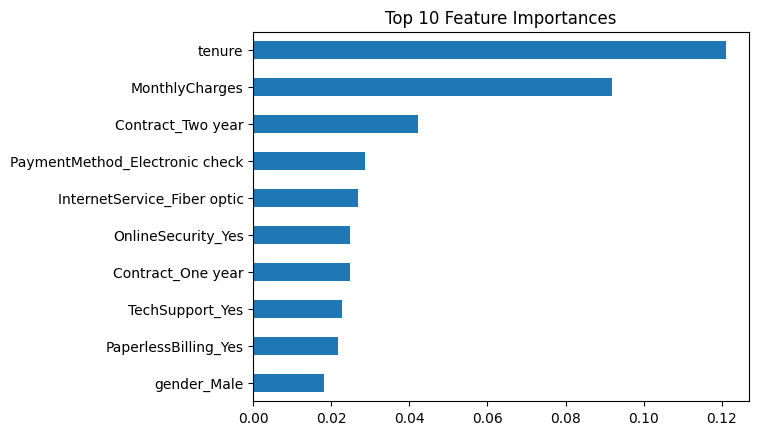

In [17]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

#Plot feature importances
importances.sort_values(ascending=True).tail(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

**Insight:** The model identifies tenure, contract type, and monthly charges as the most influential features in predicting churn. Customers with shorter tenure, month-to-month contracts, and higher monthly charges are significantly morre likely to churn. These findings strongly align with the EDA results, validating the robustness of the model.

## Final Model Selection

Although Random Forest captured non-linear patterns, Logistic Regression achieved a higher ROC-AUC score (0.84) compared to Random Forest (0.82). Given its superior performance and interpretability, Logistic Regression was selected as the final model for churn prediction.

## Business Recommendations

- Target month-to-month customers with retention offers
- Introduce loyality benefits for early-tenure users
- Review pricing strategies for high monthly charges customers
- Improve service quality for high-churn internet segments

Dataset Source:
Telco Customer Churn Dataset from Kaggle.
All credit belongs to the original dataset authors.